# Pima Indians Diabetes

| Column Name | Description |
|-------------|-------------|
| Pregnancies | Number of times pregnant |
| Glucose | Plasma glucose concentration 2 hours after an oral glucose tolerance test |
| BloodPressure | Diastolic blood pressure (mm Hg) |
| SkinThickness | Triceps skin fold thickness (mm) |
| Insulin | 2-hour serum insulin (μU/mL) |
| BMI | Body mass index (weight in kg / (height in m)^2) |
| DiabetesPedigreeFunction | Diabetes pedigree function |
| Age | Age (years) |
| Outcome | Target variable (0 = Non-diabetic, 1 = Diabetic).|

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


plt.rcParams["figure.figsize"] = (16, 8)
sns.set_style("darkgrid")
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("diabetes.csv")

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
print(f"Shape of the Dataset : {df.shape}")

Shape of the Dataset : (768, 9)


In [5]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [9]:
for col in df.columns:
    print(f"{col} -> {df[col].eq(0).sum()}")

Pregnancies -> 111
Glucose -> 5
BloodPressure -> 35
SkinThickness -> 227
Insulin -> 374
BMI -> 11
DiabetesPedigreeFunction -> 0
Age -> 0
Outcome -> 500


In [10]:
# Bir bireyin Glukoz, Kan Basıncı, Deri Kalınlığı ve Insulin değerinin 0 olması mümkün değildir.
# Bu yüzden 0 değeri, eksik ve ya hatalı ölçümleri temsil etmektedir.
# İlgili değerler Preprocessing kısmında Nan olarak ele alınıp uygun bir yöntemle doldurulacaktır.

## EDA

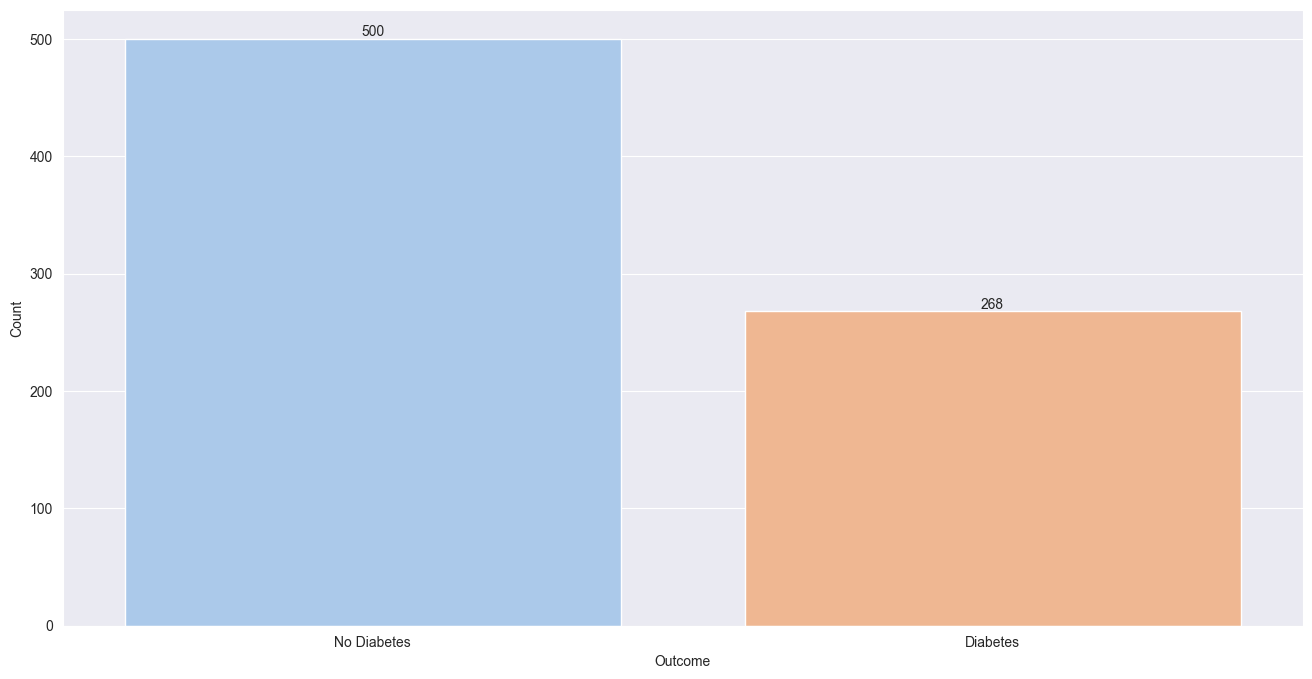

In [11]:
ax = sns.countplot(
    data= df,
    x= "Outcome",
    palette= "pastel"
)

for container in ax.containers:
    ax.bar_label(container)

ax.set_ylabel("Count")
ax.set_xticklabels(["No Diabetes", "Diabetes"])

plt.show()

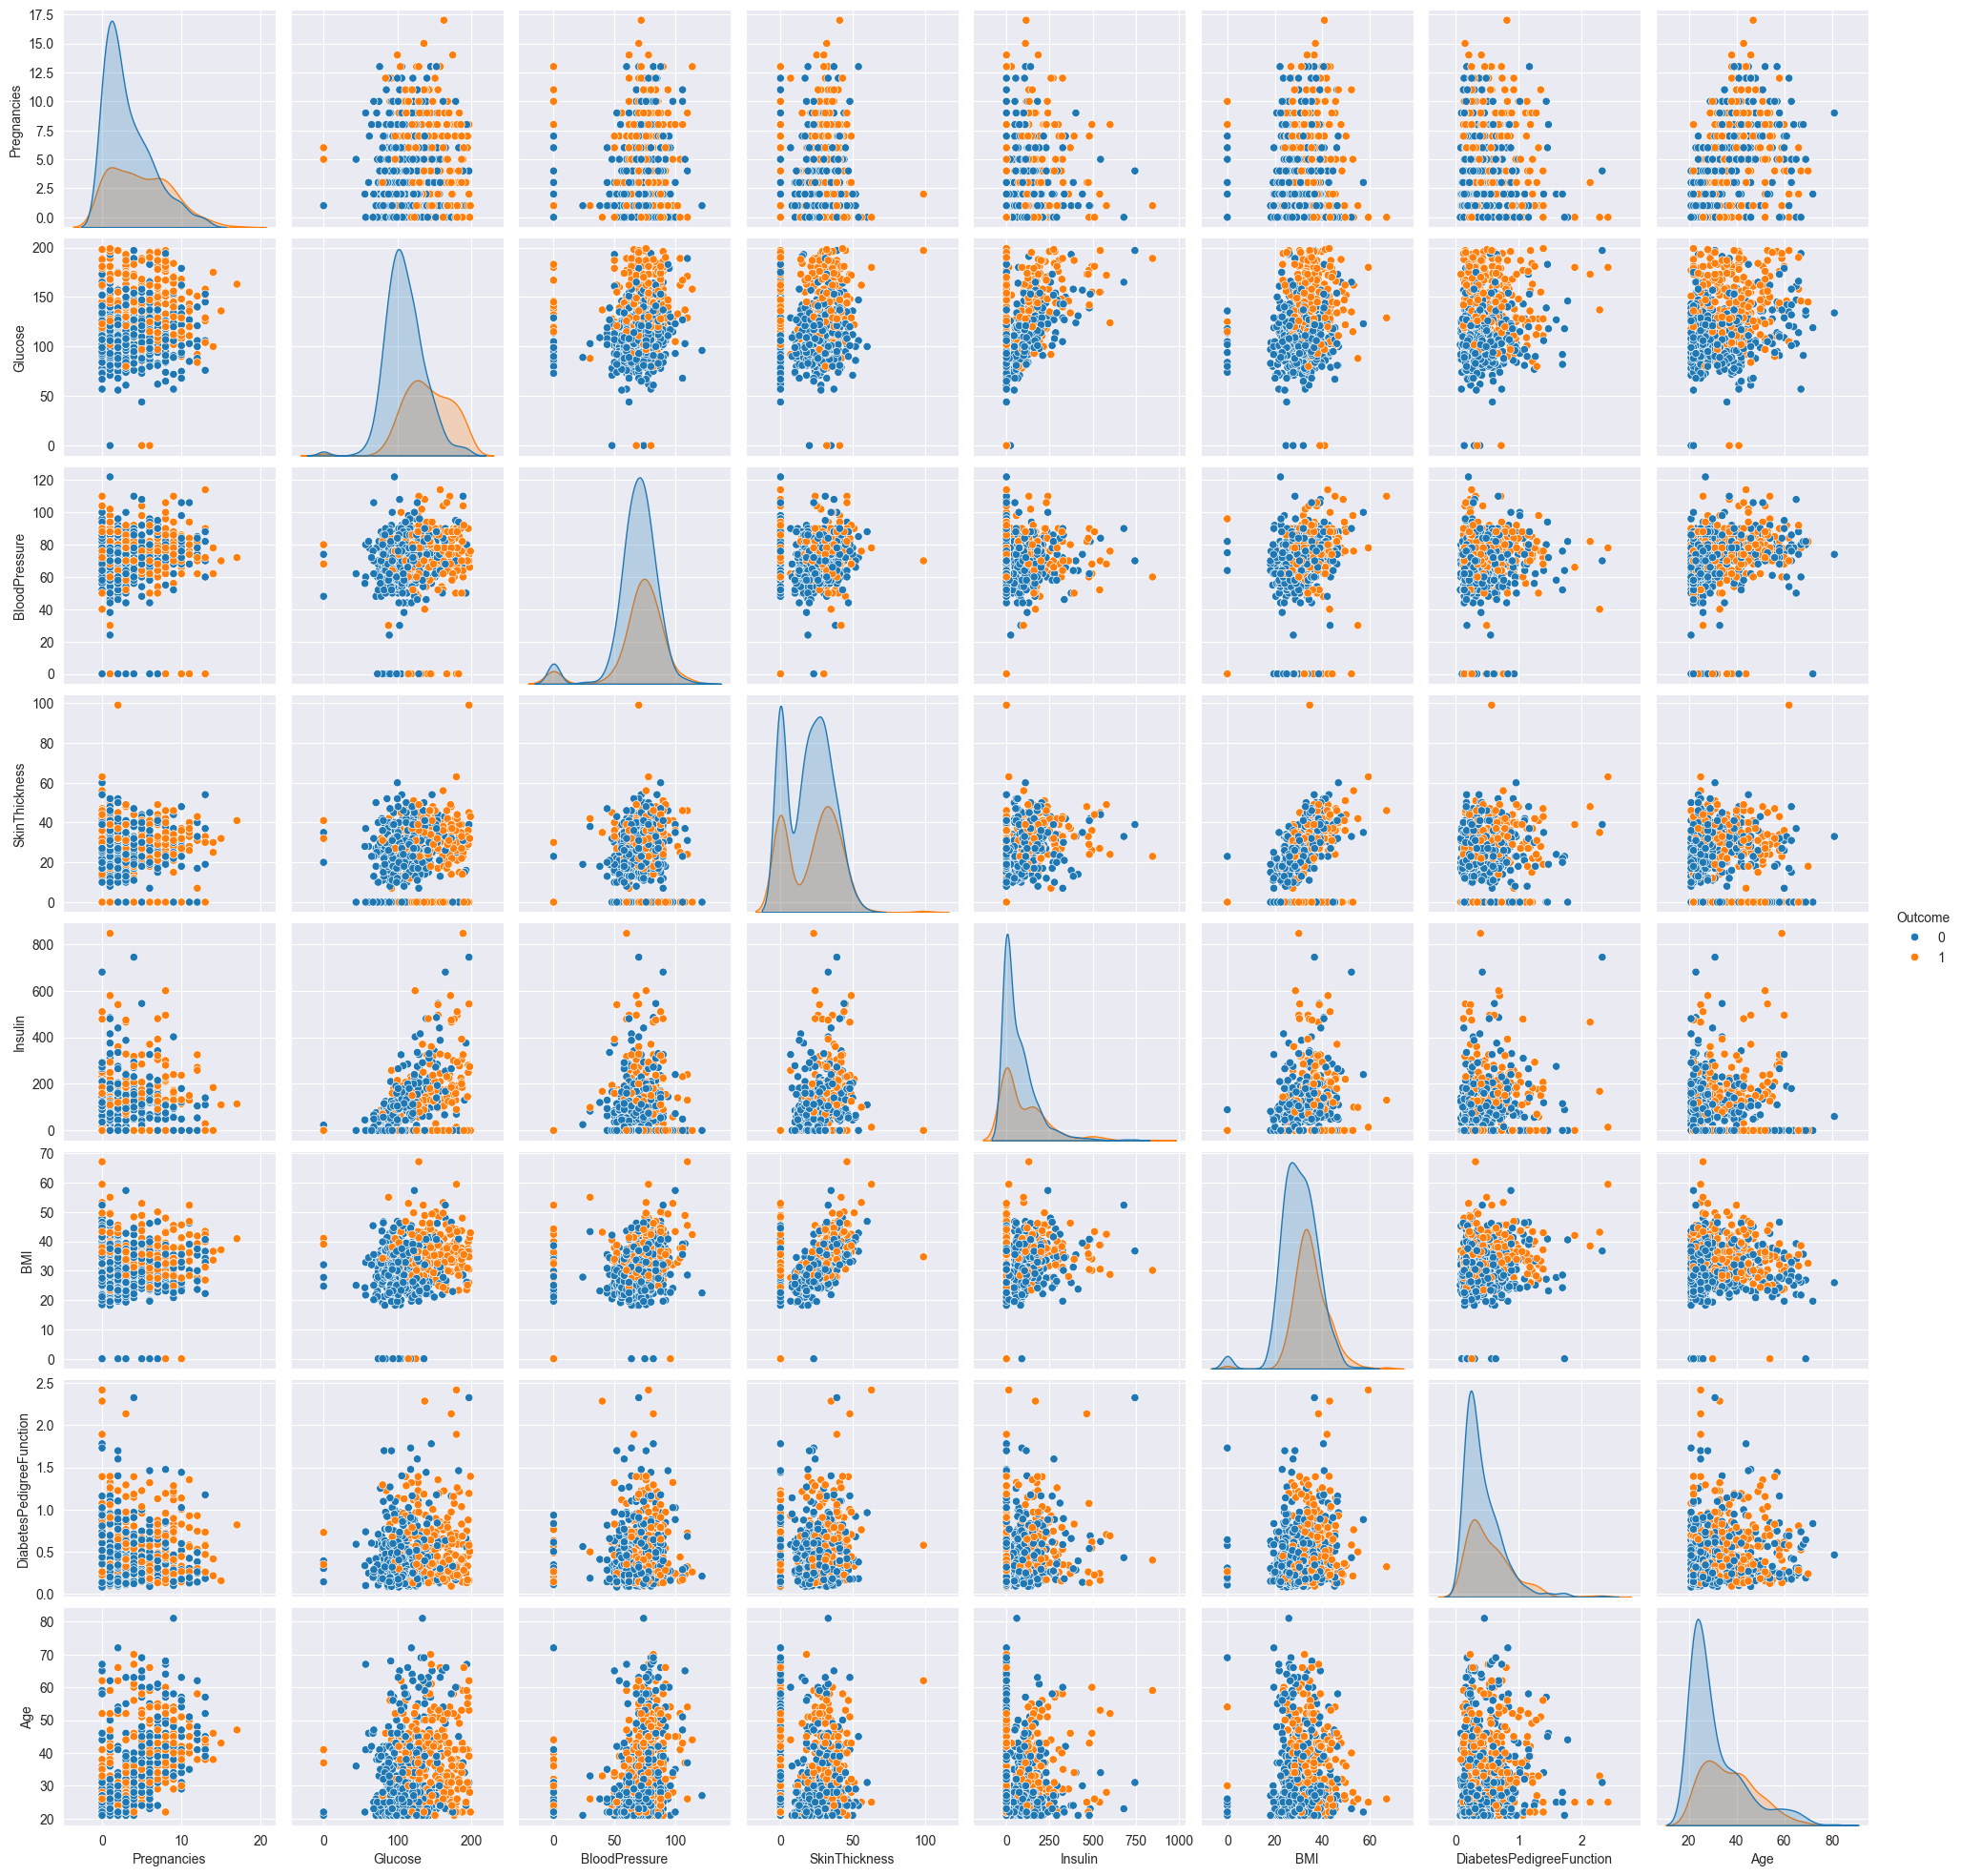

In [12]:
sns.pairplot(df, hue= "Outcome")

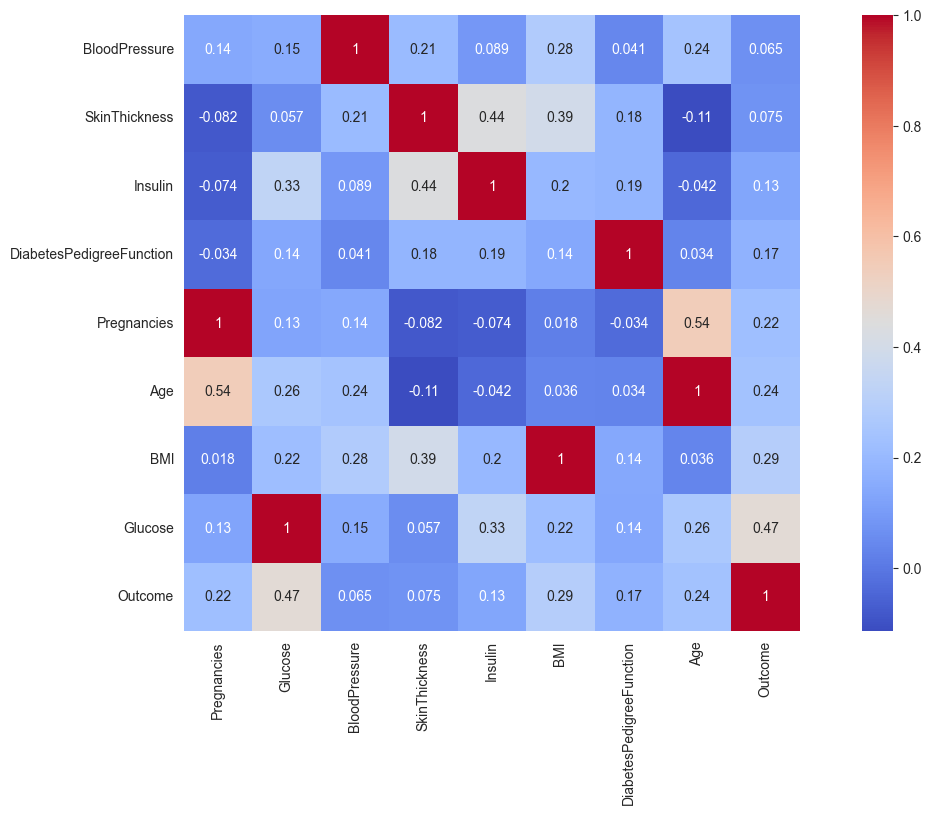

In [13]:
corr = df.corr().sort_values(by= "Outcome")

sns.heatmap(corr, cmap= "coolwarm", square= True, annot= True)

plt.show()

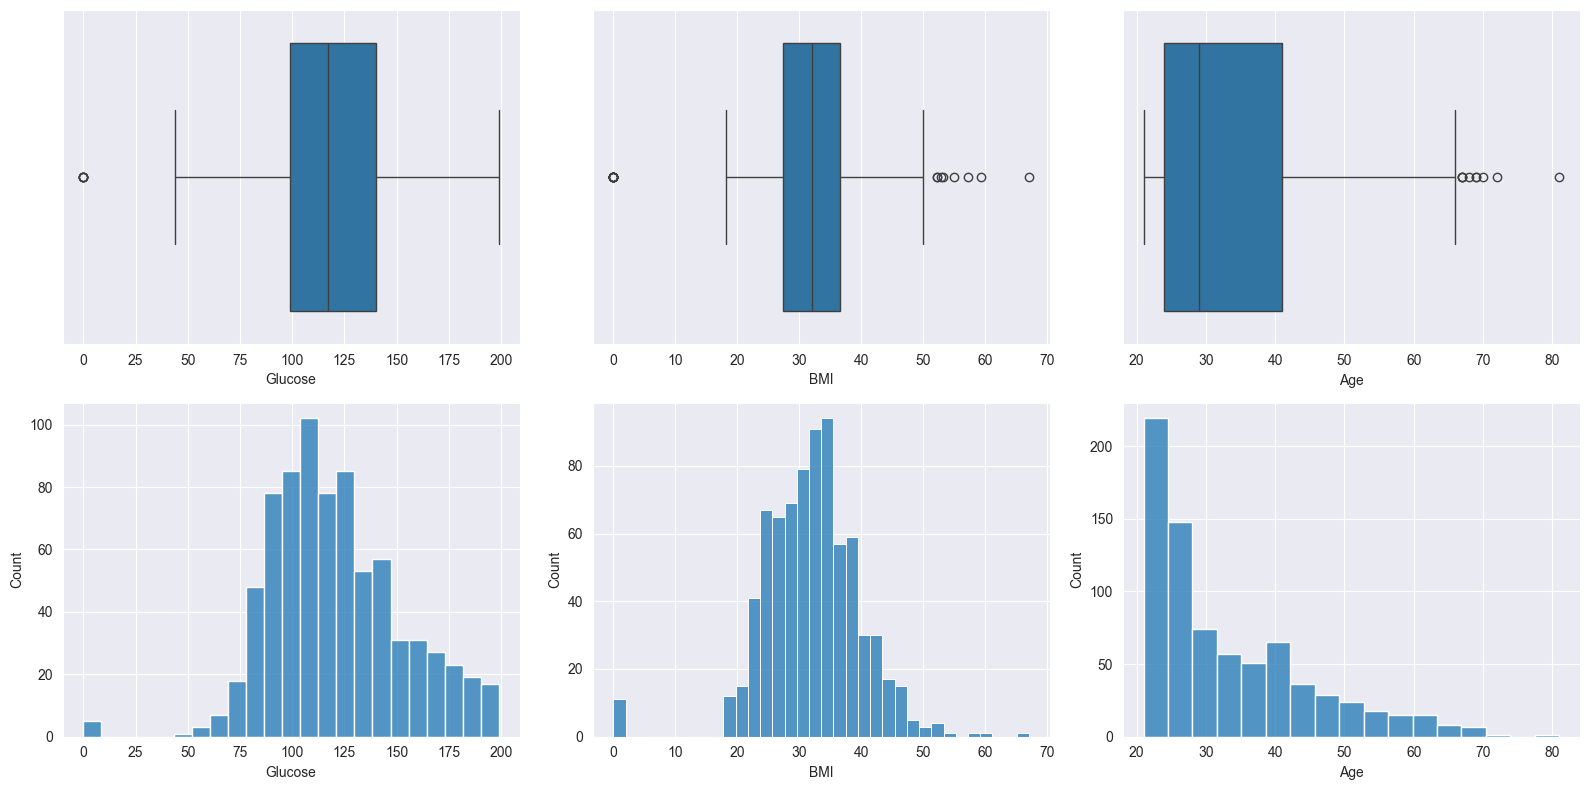

In [14]:
features = ["Glucose", "BMI", "Age"]

col = len(features)
row = 2

fig, axis = plt.subplots(row, col)
axis = axis.ravel()

for index, feature in enumerate(features):
    sns.boxplot(
    data= df,
    x= feature,
    ax= axis[index]
    )

    sns.histplot(
    data= df,
    x= feature,
    ax= axis[index + 3]
    )

plt.tight_layout()

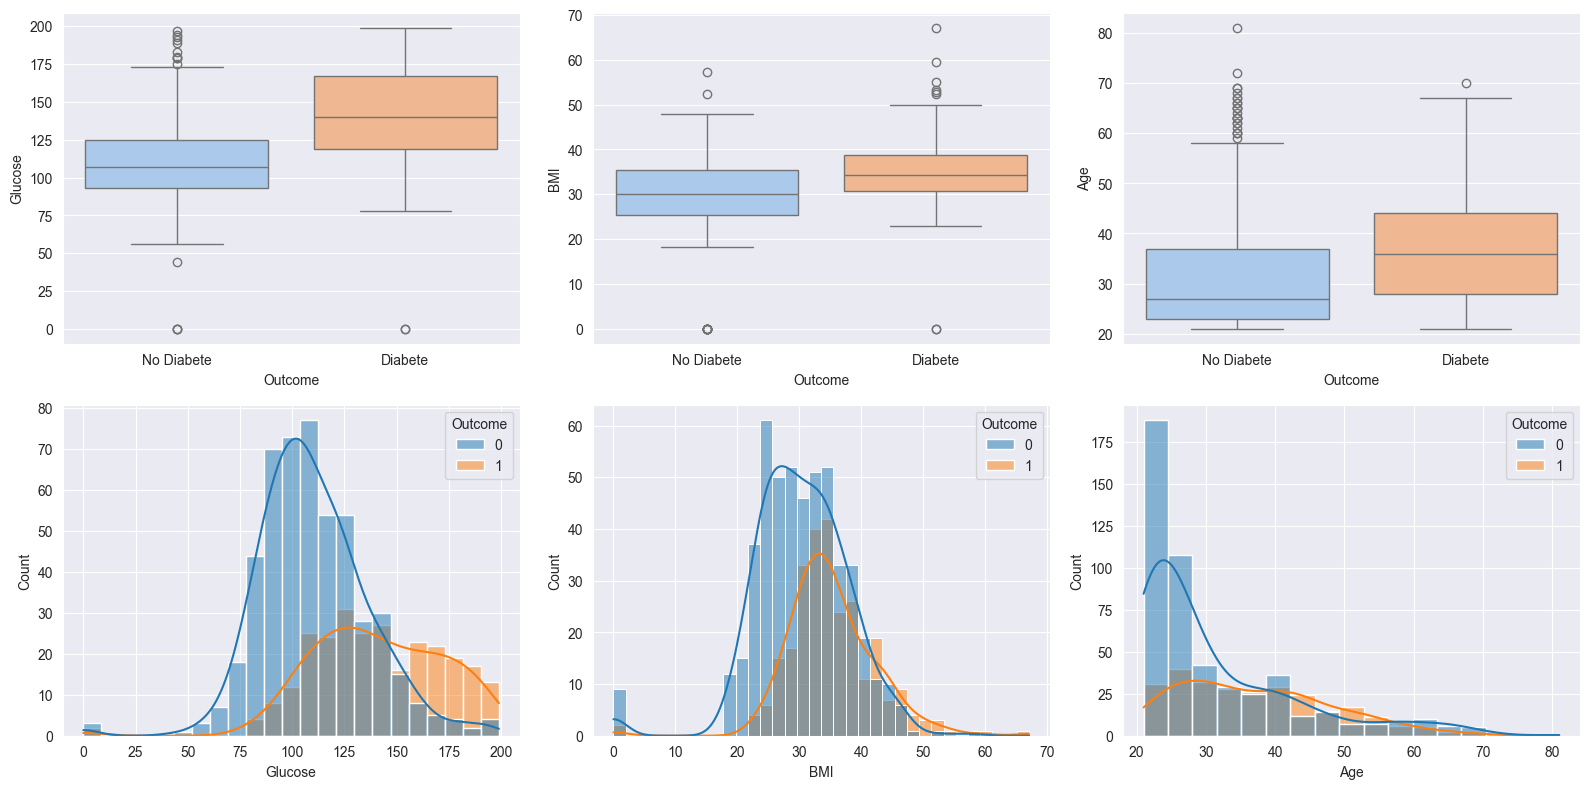

In [15]:
features = ["Glucose", "BMI", "Age"]
target = "Outcome"

col = len(features)
row = 2

fig, axis = plt.subplots(row, col)
axis = axis.ravel()

for index, feature in enumerate(features):
    sns.boxplot(
    data= df,
    x= target,
    y= feature,
    palette= "pastel",
    ax= axis[index]
    )

    axis[index].set_xticklabels(["No Diabete", "Diabete"])

    sns.histplot(
    data= df,
    x= feature,
    hue= target,
    kde= True,
    ax= axis[index + 3]
    )



plt.tight_layout()

In [16]:
# Glukoz(Kan Şekeri) ölçümlerinin, Diyabet tanısı konulan bireylerde daha yüsek çıktığı gözlemlenmiştir.
# Diyabet tanısı konulan ve konulmayan bireylerin Glukoz değerleri, belirli bir aralıkta örtüşmektedir.

# BMI(Vücüt Kitle Endeksi) ortalaması , Diyabet tanısı alan bireylerde almayanlara göre daha yüksektir.
# Diyabet tanısı konulan ve konulmayan bireylerin BMI değerleri çoğunlukla örütüştüşmekte.
# Hastalık tanısı konulan bireylerin yoğunluğu, yüksek BMI değerlerinde fazladır.

# Diyabet tanısı alan bireylerin yaş ortalaması daha yüksektir.
# Fakat tanı alan ve almayan bireylerin dağılımı oldukça örtüşmektedir.

# Bu gözlemler Glukoz, BMI ve Yaş değerlerinin hastalık tanısı koymada önemli fakat tek başına yeterli olmadığını ortaya koymaktadır.

## Preprocessing

In [17]:
X = df.drop("Outcome", axis= 1)
y = df["Outcome"]

In [18]:
# Sadece KNN Imputer ile eksik verilerin doldurulması 
# ve modelin eğitilmesi
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2 ,random_state= 42)

In [19]:
missings = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

X_train[missings] = X_train[missings].replace(0, np.nan)
X_test[missings] = X_test[missings].replace(0, np.nan)

In [20]:
X_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
60,2,84.0,NaN,NaN,NaN,NaN,0.304,21
618,9,112.0,82.0,24.0,NaN,28.2,1.282,50
346,1,139.0,46.0,19.0,83.0,28.7,0.654,22
294,0,161.0,50.0,NaN,NaN,21.9,0.254,65
231,6,134.0,80.0,37.0,370.0,46.2,0.238,46
...,...,...,...,...,...,...,...,...
71,5,139.0,64.0,35.0,140.0,28.6,0.411,26
106,1,96.0,122.0,NaN,NaN,22.4,0.207,27
270,10,101.0,86.0,37.0,NaN,45.6,1.136,38
435,0,141.0,NaN,NaN,NaN,42.4,0.205,29


In [21]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,614.0,3.742671,3.313264,0.000,1.0000,3.0000,6.00000,17.00
Glucose,609.0,121.847291,30.225545,44.000,100.0000,118.0000,139.00000,199.00
BloodPressure,590.0,72.238983,12.343231,24.000,64.0000,72.0000,80.00000,122.00
SkinThickness,438.0,28.595890,9.960502,8.000,21.0000,28.5000,36.00000,63.00
Insulin,324.0,154.330247,119.818408,14.000,78.0000,120.0000,183.25000,846.00
BMI,607.0,32.352224,6.975458,18.200,27.3000,32.0000,36.50000,67.10
DiabetesPedigreeFunction,614.0,0.469168,0.336847,0.078,0.2415,0.3725,0.61375,2.42
Age,614.0,32.907166,11.503437,21.000,24.0000,29.0000,40.00000,81.00


In [22]:
from sklearn.preprocessing import StandardScaler

In [23]:
def scale(X_train, X_test):
    scaler = StandardScaler()
    
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return X_train, X_test

In [24]:
X_train_scaled, X_test_scaled = scale(X_train, X_test)

In [25]:
X_train = pd.DataFrame(
    data= X_train_scaled,
    columns= X_train.columns,
    index= X_train.index
)

X_test = pd.DataFrame(
    data= X_test_scaled,
    columns= X_test.columns,
    index= X_test.index
)

In [26]:
X_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
60,-0.526397,-1.253192,NaN,NaN,NaN,NaN,-0.490735,-1.035940
618,1.588046,-0.326061,0.791470,-0.461939,NaN,-0.595753,2.415030,1.487101
346,-0.828460,0.567957,-2.127583,-0.964496,-0.596240,-0.524014,0.549161,-0.948939
294,-1.130523,1.296416,-1.803244,NaN,NaN,-1.499664,-0.639291,2.792122
231,0.681856,0.402398,0.629301,0.844708,1.802756,1.986851,-0.686829,1.139095
...,...,...,...,...,...,...,...,...
71,0.379793,0.567957,-0.668056,0.643686,-0.119785,-0.538362,-0.172824,-0.600933
106,-0.828460,-0.855850,4.034863,NaN,NaN,-1.427925,-0.778934,-0.513932
270,1.890109,-0.690291,1.115809,0.844708,NaN,1.900764,1.981245,0.443084
435,-1.130523,0.634181,NaN,NaN,NaN,1.441635,-0.784877,-0.339929


In [27]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,614.0,1.735854e-17,1.000815,-1.130523,-0.828460,-0.224334,0.681856,4.004552
Glucose,609.0,-1.195905e-16,1.000822,-2.577664,-0.723403,-0.127391,0.567957,2.554665
BloodPressure,590.0,4.681754e-16,1.000849,-3.911449,-0.668056,-0.019378,0.629301,4.034863
SkinThickness,438.0,-6.083414e-17,1.001144,-2.070121,-0.763473,-0.009638,0.744197,3.458003
Insulin,324.0,-6.304970e-17,1.001547,-1.173003,-0.638035,-0.286962,0.241737,5.781579
BMI,607.0,-7.316132e-16,1.000825,-2.030533,-0.724883,-0.050536,0.595115,4.985541
DiabetesPedigreeFunction,614.0,1.562268e-16,1.000815,-1.162210,-0.676430,-0.287212,0.429573,5.796175
Age,614.0,-3.761016e-17,1.000815,-1.035940,-0.774936,-0.339929,0.617087,4.184145


In [28]:
X_train.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                24
SkinThickness               176
Insulin                     290
BMI                           7
DiabetesPedigreeFunction      0
Age                           0
dtype: int64

In [29]:
# Eksik verilerin KNN ile doldurulması
from sklearn.impute import KNNImputer

In [30]:
def knn_imputer(X_train, X_test):
    imputer = KNNImputer()

    X_train = imputer.fit_transform(X_train)
    X_test = imputer.transform(X_test)

    return X_train, X_test

In [31]:
X_train_imputed, X_test_imputed = knn_imputer(X_train, X_test)

In [32]:
X_train = pd.DataFrame(
    data= X_train_imputed,
    columns= X_train.columns,
    index= X_train.index
)

X_test = pd.DataFrame(
    data= X_test_imputed,
    columns= X_test.columns,
    index= X_test.index
)

In [33]:
X_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
60,-0.526397,-1.253192,-0.230198,-1.266030,-0.870411,-0.965926,-0.490735,-1.035940
618,1.588046,-0.326061,0.791470,-0.461939,0.530536,-0.595753,2.415030,1.487101
346,-0.828460,0.567957,-2.127583,-0.964496,-0.596240,-0.524014,0.549161,-0.948939
294,-1.130523,1.296416,-1.803244,0.121027,1.854581,-1.499664,-0.639291,2.792122
231,0.681856,0.402398,0.629301,0.844708,1.802756,1.986851,-0.686829,1.139095
...,...,...,...,...,...,...,...,...
71,0.379793,0.567957,-0.668056,0.643686,-0.119785,-0.538362,-0.172824,-0.600933
106,-0.828460,-0.855850,4.034863,-0.843882,-0.556118,-1.427925,-0.778934,-0.513932
270,1.890109,-0.690291,1.115809,0.844708,0.102561,1.900764,1.981245,0.443084
435,-1.130523,0.634181,0.304961,1.166345,0.918387,1.441635,-0.784877,-0.339929


In [34]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,614.0,1.735854e-17,1.000815,-1.130523,-0.828460,-0.224334,0.681856,4.004552
Glucose,614.0,-2.504225e-03,0.998937,-2.577664,-0.723403,-0.127391,0.567957,2.554665
BloodPressure,614.0,-3.055285e-03,0.987997,-3.911449,-0.668056,-0.019378,0.629301,4.034863
SkinThickness,614.0,4.571022e-03,0.911428,-2.070121,-0.662962,-0.029740,0.643686,3.458003
Insulin,614.0,-3.983011e-03,0.831534,-1.173003,-0.547341,-0.207553,0.319892,5.781579
BMI,614.0,-1.975903e-04,0.996945,-2.030533,-0.724883,-0.050536,0.591528,4.985541
DiabetesPedigreeFunction,614.0,1.562268e-16,1.000815,-1.162210,-0.676430,-0.287212,0.429573,5.796175
Age,614.0,-3.761016e-17,1.000815,-1.035940,-0.774936,-0.339929,0.617087,4.184145


In [35]:
X_train.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

In [36]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [37]:
ada = AdaBoostClassifier()

In [38]:
ada.fit(X_train, y_train)
predicts = ada.predict(X_test)

KNN_imputation_score = accuracy_score(y_test, predicts)

print(f"Score : {KNN_imputation_score:.2%}")
print(f"Classification Report\n {classification_report(y_test, predicts)}")
print(f"Confusion Matrix\n {confusion_matrix(y_test, predicts)}")


Score : 74.68%
Classification Report
               precision    recall  f1-score   support

           0       0.82      0.78      0.80        99
           1       0.63      0.69      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154

Confusion Matrix
 [[77 22]
 [17 38]]


In [39]:
# Sadece medyan ile eksik verilerin doldurulması 
# ve modelin eğitilmesi

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2 ,random_state= 42)

In [40]:
missings = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

X_train[missings] = X_train[missings].replace(0, X_train[missings].median())
X_test[missings] = X_test[missings].replace(0, X_train[missings].median())

In [41]:
ada = AdaBoostClassifier()

ada.fit(X_train, y_train)
predicts = ada.predict(X_test)

median_imputation_score = accuracy_score(y_test, predicts)

print(f"Score : {median_imputation_score:.2%}")
print(f"Classification Report\n {classification_report(y_test, predicts)}")
print(f"Confusion Matrix\n {confusion_matrix(y_test, predicts)}")


Score : 75.97%
Classification Report
               precision    recall  f1-score   support

           0       0.82      0.80      0.81        99
           1       0.66      0.69      0.67        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154

Confusion Matrix
 [[79 20]
 [17 38]]


In [42]:
# Hem medyan hem de KNN Imputer ile eksik verilerin doldurulması
# ve modelin eğitilmesi

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2 ,random_state= 42)

In [43]:
knn_impute = ["Glucose", "BloodPressure", "SkinThickness", "BMI"]
insulin_median = X_train["Insulin"].median()

X_train["Insulin"] = X_train["Insulin"].replace(0, insulin_median)
X_train[knn_impute] = X_train[knn_impute].replace(0, np.nan)

X_test["Insulin"] = X_test["Insulin"].replace(0, insulin_median)
X_test[knn_impute] = X_test[knn_impute].replace(0, np.nan)


In [44]:
X_train["Insulin"].isnull().sum()

np.int64(0)

In [45]:
X_train, X_test = scale(X_train, X_test)

In [46]:
# X_train = pd.DataFrame(data= X_train_scaled,
#                         columns= X_train.columns,
#                         index= X_train.index ) 

# X_test = pd.DataFrame(data= X_test_scaled,
#                       columns= X_test.columns,
#                       index= X_test.index)

In [47]:
X_train, X_test = knn_imputer(X_train, X_test)

In [48]:
# X_train = pd.DataFrame( data= X_train_imputed, columns= X_train.columns, index= X_train.index ) 
# X_test = pd.DataFrame( data= X_test_imputed, columns= X_test.columns, index= X_test.index )

In [49]:
ada = AdaBoostClassifier()

ada.fit(X_train, y_train)
predicts = ada.predict(X_test)

mixed_imputation_score = accuracy_score(y_test, predicts)

print(f"Score : {mixed_imputation_score:.2%}")
print(f"Classification Report\n {classification_report(y_test, predicts)}")
print(f"Confusion Matrix\n {confusion_matrix(y_test, predicts)}")


Score : 77.92%
Classification Report
               precision    recall  f1-score   support

           0       0.84      0.81      0.82        99
           1       0.68      0.73      0.70        55

    accuracy                           0.78       154
   macro avg       0.76      0.77      0.76       154
weighted avg       0.78      0.78      0.78       154

Confusion Matrix
 [[80 19]
 [15 40]]


In [50]:
print(f"Imputation with just KNN Imputer score : {KNN_imputation_score:.2%}")
print(f"Imputation with just Median Imputation : {median_imputation_score:.2%}")
print(f"Imputation with both KNN Imputation and Median Imputation Score : {mixed_imputation_score:.2%}")

Imputation with just KNN Imputer score : 74.68%
Imputation with just Median Imputation : 75.97%
Imputation with both KNN Imputation and Median Imputation Score : 77.92%


In [51]:
# Açıkça görüldüğü üzere KNNImputer ve Medyan yardımıyla eksik verilerin doldurulması
# daha yüksek doğruluk göstermiştir.

In [52]:
#Hyperparam Tuning

In [53]:
params = {
    "n_estimators" :  [50, 70, 100, 200 ,300, 500],
    "learning_rate" : [0.001 ,0.01, 0.1, 1, 2, 3 ,5]
}

In [54]:
from sklearn.model_selection import GridSearchCV

In [55]:
grid = GridSearchCV(
    estimator= AdaBoostClassifier(),
    param_grid= params,
    cv= 5,
    n_jobs= -1
)

In [56]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=AdaBoostClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.001, 0.01, 0.1, 1, 2, 3, 5],
                         'n_estimators': [50, 70, 100, 200, 300, 500]})

In [57]:
grid.best_estimator_

AdaBoostClassifier(learning_rate=1, n_estimators=300)

In [58]:
grid.best_params_

{'learning_rate': 1, 'n_estimators': 300}

In [59]:
predicts = grid.predict(X_test)

print(f"Score : {accuracy_score(y_test, predicts):.2%}")
print(f"Classification Report\n {classification_report(y_test, predicts)}")
print(f"Confusion Matrix\n {confusion_matrix(y_test, predicts)}")

Score : 74.03%
Classification Report
               precision    recall  f1-score   support

           0       0.80      0.80      0.80        99
           1       0.64      0.64      0.64        55

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.74      0.74      0.74       154

Confusion Matrix
 [[79 20]
 [20 35]]


In [60]:
# Model performansları karşılaştırma

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [65]:
classifiers = {
    "Logistic Regression" : LogisticRegression(),
    "Support Vector Classifier" : SVC(),
    "Decision Tree Classifier" : DecisionTreeClassifier(),
    "K-Nearest Neighbors" : KNeighborsClassifier(),
    "Random Forest" : RandomForestClassifier(),
    "AdaBoost" : AdaBoostClassifier()
}

In [66]:
def model_evaluation(models):
    results = []
    for name, model in models.items():
        model.fit(X_train, y_train)

        predicts = model.predict(X_test)

        score = accuracy_score(y_test, predicts)

        results.append({
            "Model" : name,
            "Score" : score
        })


    results = pd.DataFrame(results).sort_values(by= "Score", ascending= False).reset_index(drop= True)
    results["Score"] = results["Score"].map(lambda x:  f"{x:.2%}")

    return results

In [67]:
result = model_evaluation(classifiers)
print(result)

                       Model   Score
0                   AdaBoost  77.92%
1        Logistic Regression  75.97%
2   Decision Tree Classifier  75.32%
3  Support Vector Classifier  74.03%
4              Random Forest  73.38%
5        K-Nearest Neighbors  71.43%
